In [ ]:
!pip install -q torch datasets scikit-learn pandas matplotlib

In [ ]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from datasets import load_dataset
import matplotlib.pyplot as plt

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## Part A. Softmax и Cross-Entropy

In [ ]:
# A1: ручной softmax
logits = torch.tensor([2.0, 1.0, 0.1])
exp_logits = torch.exp(logits)
denom = exp_logits.sum()
probs_manual = exp_logits / denom
probs_torch = torch.softmax(logits, dim=0)

print('exp(logits)=', exp_logits)
print('denominator=', denom.item())
print('manual probs=', probs_manual)
print('sum probs=', probs_manual.sum().item())
print('torch probs=', probs_torch)

# A2: численно стабильный softmax
large_logits = torch.tensor([1000.0, 999.0, 998.0])
shifted = large_logits - large_logits.max()
probs_stable = torch.exp(shifted) / torch.exp(shifted).sum()
print('\nstable probs=', probs_stable)

# A3: cross-entropy
logits3 = torch.tensor([[2.0, 1.0, 0.1]])
true_class = torch.tensor([0])
loss = nn.CrossEntropyLoss()(logits3, true_class)
loss_wrong = nn.CrossEntropyLoss()(torch.tensor([[0.1, 0.1, 2.0]]), true_class)
print('\nCE(correct)=', float(loss))
print('CE(confident wrong)=', float(loss_wrong))

exp(logits)= tensor([7.3891, 2.7183, 1.1052])
denominator= 11.212509155273438
manual probs= tensor([0.6590, 0.2424, 0.0986])
sum probs= 0.9999999403953552
torch probs= tensor([0.6590, 0.2424, 0.0986])

stable probs= tensor([0.6652, 0.2447, 0.0900])

CE(correct)= 0.4170299470424652
CE(confident wrong)= 2.1617002487182617


## Part B. Autoregressive Char-RNN



In [ ]:
def load_names():
    try:
        df = pd.read_csv('StateGrants.csv')
        col = None
        for c in df.columns:
            if df[c].dtype == 'object':
                col = c
                break
        if col is None:
            raise ValueError('Нет текстовой колонки')
        names = [str(x).strip().lower() for x in df[col].dropna().tolist()]
    except Exception:
        names = [
            'anna','aiman','nurbol','alina','asset','dias','azhar','dana','erlan','gulmira',
            'marat','nursultan','aigerim','aliya','askar','bekzat','kamila','sanzhar','arman','madina'
        ]
    names = [n for n in names if len(n) >= 2 and any(ch.isalpha() for ch in n)]
    return names

names = load_names()
print('Количество строк:', len(names), '| Пример:', names[:5])

chars = sorted(set(''.join(names)))
char2idx = {'<PAD>': 0, '<S>': 1, '<F>': 2, '<UNK>': 3}
for ch in chars:
    if ch not in char2idx:
        char2idx[ch] = len(char2idx)
idx2char = {i: ch for ch, i in char2idx.items()}

X, Y = [], []
for n in names:
    x = [char2idx['<S>']] + [char2idx.get(c, char2idx['<UNK>']) for c in n]
    y = [char2idx.get(c, char2idx['<UNK>']) for c in n] + [char2idx['<F>']]
    X.append(x)
    Y.append(y)

max_len = max(max(len(s) for s in X), max(len(s) for s in Y))

class CharDataset(Dataset):
    def __init__(self, xs, ys, max_len, pad_idx):
        self.xs, self.ys = xs, ys
        self.max_len, self.pad = max_len, pad_idx
    def __len__(self):
        return len(self.xs)
    def __getitem__(self, i):
        x = self.xs[i][:self.max_len] + [self.pad] * (self.max_len - len(self.xs[i]))
        y = self.ys[i][:self.max_len] + [self.pad] * (self.max_len - len(self.ys[i]))
        return torch.tensor(x), torch.tensor(y)

idx = list(range(len(X)))
tr_idx, va_idx = train_test_split(idx, test_size=0.2, random_state=seed)
X_tr, Y_tr = [X[i] for i in tr_idx], [Y[i] for i in tr_idx]
X_va, Y_va = [X[i] for i in va_idx], [Y[i] for i in va_idx]

train_loader = DataLoader(CharDataset(X_tr, Y_tr, max_len, 0), batch_size=16, shuffle=True)
val_loader = DataLoader(CharDataset(X_va, Y_va, max_len, 0), batch_size=16, shuffle=False)

xb, yb = next(iter(train_loader))
print('x_batch shape:', tuple(xb.shape), '| y_batch shape:', tuple(yb.shape))
print('vocab_size:', len(char2idx), '| max_len:', max_len)

Количество строк: 20 | Пример: ['anna', 'aiman', 'nurbol', 'alina', 'asset']
x_batch shape: (16, 10) | y_batch shape: (16, 10)
vocab_size: 22 | max_len: 10


In [ ]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.GRU(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
    def forward(self, x, hidden=None):
        emb = self.embedding(x)
        out, h = self.rnn(emb, hidden)
        logits = self.fc(out)
        return logits, h

char_model = CharRNN(len(char2idx), 32, 64, 0).to(device)
char_opt = torch.optim.Adam(char_model.parameters(), lr=1e-3)
char_crit = nn.CrossEntropyLoss(ignore_index=0)

def char_eval(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            loss = char_crit(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            total_loss += loss.item()
            pred = logits.argmax(-1)
            mask = y != 0
            correct += (pred[mask] == y[mask]).sum().item()
            total += mask.sum().item()
    return total_loss / len(loader), (correct / total if total else 0.0)

char_train_losses, char_val_losses = [], []
for ep in range(12):
    char_model.train()
    tr_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits, _ = char_model(x)
        loss = char_crit(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        char_opt.zero_grad()
        loss.backward()
        char_opt.step()
        tr_loss += loss.item()
    tr_loss /= len(train_loader)
    va_loss, va_acc = char_eval(char_model, val_loader)
    char_train_losses.append(tr_loss)
    char_val_losses.append(va_loss)
    if (ep + 1) % 2 == 0:
        print(f'Epoch {ep+1}: train_loss={tr_loss:.4f}, val_loss={va_loss:.4f}, val_next_char_acc={va_acc:.3f}')

char_model.eval()
x_ex, y_ex = next(iter(val_loader))
x_ex = x_ex[:1].to(device)
y_ex = y_ex[:1].to(device)
with torch.no_grad():
    logits_ex, _ = char_model(x_ex)
pred_ex = logits_ex.argmax(-1)[0].cpu().tolist()
x_list = x_ex[0].cpu().tolist()
y_list = y_ex[0].cpu().tolist()

def decode(ids):
    out = []
    for i in ids:
        if i == 0:
            continue
        t = idx2char.get(i, '?')
        out.append(t)
        if t == '<F>':
            break
    return out

print('Input chars :', decode(x_list))
print('Target chars:', decode(y_list))
print('Pred chars  :', decode(pred_ex))

Epoch 2: train_loss=3.0798, val_loss=3.0121, val_next_char_acc=0.038
Epoch 4: train_loss=3.0351, val_loss=2.9772, val_next_char_acc=0.115
Epoch 6: train_loss=2.9907, val_loss=2.9426, val_next_char_acc=0.192
Epoch 8: train_loss=2.9460, val_loss=2.9076, val_next_char_acc=0.192
Epoch 10: train_loss=2.9002, val_loss=2.8719, val_next_char_acc=0.385
Epoch 12: train_loss=2.8530, val_loss=2.8350, val_next_char_acc=0.385
Input chars : ['<S>', 'a', 'n', 'n', 'a']
Target chars: ['a', 'n', 'n', 'a', '<F>']
Pred chars  : ['a', 'n', 'a', 'a', '<F>']


## Part C. Генерация текста (autoregressive)

In [ ]:
def generate(start_text='', max_len=30, temperature=1.0, greedy=False):
    char_model.eval()
    out_text = ''
    hidden = None
    prev_idx = char2idx['<S>']

    for ch in start_text:
        x = torch.tensor([[prev_idx]], dtype=torch.long, device=device)
        with torch.no_grad():
            _, hidden = char_model(x, hidden)
        prev_idx = char2idx.get(ch, char2idx['<UNK>'])
        out_text += ch

    for _ in range(max_len):
        x = torch.tensor([[prev_idx]], dtype=torch.long, device=device)
        with torch.no_grad():
            logits, hidden = char_model(x, hidden)
        step_logits = logits[0, -1] / temperature
        probs = torch.softmax(step_logits, dim=-1)
        next_idx = int(torch.argmax(probs)) if greedy else int(torch.multinomial(probs, 1))
        next_char = idx2char[next_idx]
        if next_char == '<F>':
            break
        if next_char not in ['<S>', '<PAD>']:
            out_text += next_char
        prev_idx = next_idx
    return out_text

prefixes = ['a', 'ai', 'nur']

print('Greedy (5 примеров):')
for i in range(5):
    p = prefixes[i % len(prefixes)]
    print(f'{i+1}. {p} -> {generate(start_text=p, greedy=True)}')

for t in [0.5, 1.0, 1.5]:
    print(f'\nSampling temperature={t} (5 примеров):')
    for i in range(5):
        p = prefixes[i % len(prefixes)]
        print(f'{i+1}. {p} -> {generate(start_text=p, temperature=t, greedy=False)}')

Greedy (5 примеров):
1. a -> ana
2. ai -> aia
3. nur -> nura
4. a -> ana
5. ai -> aia

Sampling temperature=0.5 (5 примеров):
1. a -> asremra
2. ai -> aigka
3. nur -> nurgz
4. a -> an
5. ai -> airigtrar

Sampling temperature=1.0 (5 примеров):
1. a -> am
2. ai -> aiadlmg
3. nur -> nuro
4. a -> ardur
5. ai -> ai

Sampling temperature=1.5 (5 примеров):
1. a -> ailuhdgztls<UNK><UNK>mlgdk
2. ai -> aithklhbrod
3. nur -> nuraysublnamhokim
4. a -> aaua<UNK>grabibkoakmyyrzlnunldlrkh
5. ai -> aihtkm


## Part D. NER (many-to-many)

In [ ]:
try:
    ner_ds = load_dataset('eriktks/conll2003')
    train_raw = ner_ds['train'].select(range(700))
    val_raw = ner_ds['validation'].select(range(120))
    label_names = train_raw.features['ner_tags'].feature.names
except Exception:
    label_names = ['O', 'B-ORG', 'I-ORG', 'B-PER', 'I-PER', 'B-LOC', 'I-LOC']
    fallback = [
        {'tokens':['Apple','opened','office','in','Almaty'], 'ner_tags':[1,0,0,0,5]},
        {'tokens':['Nazarbayev','University','is','in','Almaty'], 'ner_tags':[3,0,0,0,5]},
        {'tokens':['Google','hired','Aigerim'], 'ner_tags':[1,0,3]},
        {'tokens':['Astana','is','a','city'], 'ner_tags':[5,0,0,0]},
        {'tokens':['Kaspi','Bank','is','popular'], 'ner_tags':[1,0,0,0]},
        {'tokens':['Alibek','works','at','Microsoft'], 'ner_tags':[3,0,0,1]},
        {'tokens':['KBTU','is','in','Almaty'], 'ner_tags':[1,0,0,5]},
        {'tokens':['Dana','lives','in','Astana'], 'ner_tags':[3,0,0,5]}
    ]
    split = int(len(fallback) * 0.75)
    train_raw, val_raw = fallback[:split], fallback[split:]

PAD_TOKEN, UNK_TOKEN, PAD_TAG = '<PAD>', '<UNK>', '<PAD>'
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
tag2idx = {PAD_TAG: 0}
for t in label_names:
    if t not in tag2idx:
        tag2idx[t] = len(tag2idx)
idx2tag = {i: t for t, i in tag2idx.items()}

def iter_examples(data):
    for ex in data:
        yield ex['tokens'], ex['ner_tags']

for tokens, _ in iter_examples(train_raw):
    for w in tokens:
        w = w.lower()
        if w not in word2idx:
            word2idx[w] = len(word2idx)

max_seq_len = 35

def to_ids(tokens, tags):
    x = [word2idx.get(w.lower(), word2idx[UNK_TOKEN]) for w in tokens][:max_seq_len]
    y = [tag2idx[label_names[t] if isinstance(t, int) else t] for t in tags][:max_seq_len]
    x += [word2idx[PAD_TOKEN]] * (max_seq_len - len(x))
    y += [tag2idx[PAD_TAG]] * (max_seq_len - len(y))
    return x, y

class NERDataset(Dataset):
    def __init__(self, data):
        self.items = []
        for toks, tags in iter_examples(data):
            x, y = to_ids(toks, tags)
            self.items.append((torch.tensor(x), torch.tensor(y), toks))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        return self.items[i][0], self.items[i][1], self.items[i][2]

train_ner_ds = NERDataset(train_raw)
val_ner_ds = NERDataset(val_raw)

def ner_collate(batch):
    xs = torch.stack([b[0] for b in batch])
    ys = torch.stack([b[1] for b in batch])
    toks = [b[2] for b in batch]
    return xs, ys, toks

train_ner_loader = DataLoader(train_ner_ds, batch_size=32, shuffle=True, collate_fn=ner_collate)
val_ner_loader = DataLoader(val_ner_ds, batch_size=32, shuffle=False, collate_fn=ner_collate)

xb, yb, _ = next(iter(train_ner_loader))
print('x_batch shape:', tuple(xb.shape), '| tag_batch shape:', tuple(yb.shape))
print('word_vocab:', len(word2idx), '| tag_vocab:', len(tag2idx))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

conll2003.py: 0.00B [00:00, ?B/s]

x_batch shape: (6, 35) | tag_batch shape: (6, 35)
word_vocab: 23 | tag_vocab: 8


In [ ]:
class BiRNNNER(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_tags, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(embed_dim, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_tags)
    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.rnn(emb)
        return self.fc(out)

ner_model = BiRNNNER(len(word2idx), 64, 64, len(tag2idx), word2idx[PAD_TOKEN]).to(device)
ner_opt = torch.optim.Adam(ner_model.parameters(), lr=1e-3)
ner_crit = nn.CrossEntropyLoss(ignore_index=tag2idx[PAD_TAG])

def ner_eval(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y, _ in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = ner_crit(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
            total_loss += loss.item()
            pred = logits.argmax(-1)
            mask = y != tag2idx[PAD_TAG]
            correct += (pred[mask] == y[mask]).sum().item()
            total += mask.sum().item()
    return total_loss / len(loader), (correct / total if total else 0.0)

ner_train_losses = []
for ep in range(4):
    ner_model.train()
    tr_loss = 0.0
    for x, y, _ in train_ner_loader:
        x, y = x.to(device), y.to(device)
        logits = ner_model(x)
        loss = ner_crit(logits.reshape(-1, logits.size(-1)), y.reshape(-1))
        ner_opt.zero_grad()
        loss.backward()
        ner_opt.step()
        tr_loss += loss.item()
    tr_loss /= len(train_ner_loader)
    ner_train_losses.append(tr_loss)
    va_loss, va_acc = ner_eval(ner_model, val_ner_loader)
    print(f'Epoch {ep+1}: train_loss={tr_loss:.4f}, val_loss={va_loss:.4f}, val_token_acc={va_acc:.3f}')

print('\nПримеры NER (token | true | pred):')
shown = 0
ner_model.eval()
with torch.no_grad():
    for x, y, toks_batch in val_ner_loader:
        x, y = x.to(device), y.to(device)
        pred = ner_model(x).argmax(-1).cpu()
        y_cpu = y.cpu()
        for i in range(x.size(0)):
            toks = toks_batch[i]
            if shown >= 5:
                break
            print(f'\nSentence {shown+1}:')
            for j, tok in enumerate(toks):
                true_tag = idx2tag[int(y_cpu[i, j])]
                pred_tag = idx2tag[int(pred[i, j])]
                print(f'{tok:12} {true_tag:8} {pred_tag:8}')
            shown += 1
        if shown >= 5:
            break

Epoch 1: train_loss=2.0624, val_loss=1.9896, val_token_acc=0.500
Epoch 2: train_loss=2.0135, val_loss=1.9546, val_token_acc=0.625
Epoch 3: train_loss=1.9653, val_loss=1.9200, val_token_acc=0.625
Epoch 4: train_loss=1.9174, val_loss=1.8854, val_token_acc=0.625

Примеры NER (token | true | pred):

Sentence 1:
KBTU         B-ORG    O       
is           O        O       
in           O        O       
Almaty       B-LOC    B-LOC   

Sentence 2:
Dana         B-PER    O       
lives        O        O       
in           O        O       
Astana       B-LOC    B-ORG   


## Part E. Сравнение двух задач + ответы

In [ ]:
table = pd.DataFrame([
    {
        'Task': 'Character generation',
        'Input': 'previous characters',
        'Target': 'next character',
        'Output shape': '(batch, seq_len, vocab_size)',
        'Uses softmax over': 'character vocabulary',
        'Decoding method': 'greedy/sampling autoregressive'
    },
    {
        'Task': 'NER',
        'Input': 'sentence tokens',
        'Target': 'tag per token',
        'Output shape': '(batch, seq_len, num_tags)',
        'Uses softmax over': 'tag vocabulary',
        'Decoding method': 'per-token argmax'
    }
])
print(table.to_string(index=False))

                Task               Input         Target                 Output shape    Uses softmax over                Decoding method
Character generation previous characters next character (batch, seq_len, vocab_size) character vocabulary greedy/sampling autoregressive
                 NER     sentence tokens  tag per token   (batch, seq_len, num_tags)       tag vocabulary               per-token argmax


## Bonus: графики losses


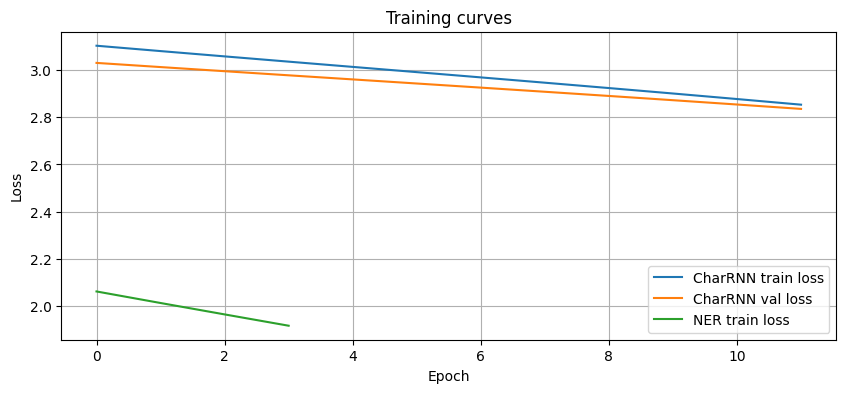

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(char_train_losses, label='CharRNN train loss')
plt.plot(char_val_losses, label='CharRNN val loss')
plt.plot(ner_train_losses, label='NER train loss')
plt.title('Training curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()